# ARD (Automatic Relevance Determination) チュートリアル

PHYSBOではサロゲートモデルにガウス過程 (GP) を用いており、カーネルとしてガウスカーネルを用います。

$$k(\vec{x}, \vec{x}') = \lambda^2 \exp\left[ -\frac{1}{2} \frac{\|\vec{x} - \vec{x}'\|^2}{\eta^2} \right] $$

$\lambda$ と $\eta$ とはそれぞれカーネルの値と入力の長さスケールとを表すハイパーパラメータです。

**ARD** カーネルでは、各入力次元 $i$ ごとに異なる長さスケール $\eta_i$ を設定します。これらを別々に学習することで、目的関数に効く次元と効かない次元を自動的に識別し、効率的な最適化を行えます。

$$k(\vec{x}, \vec{x}') = \lambda^2 \exp\left[ -\frac{1}{2} \sum_i \frac{(x_i - x_i')^2}{\eta_i^2} \right] $$

PHYSBOでは、 `policy.bayes_search` 関数でベイズ最適化を行うときに `ard=True` というキーワード引数を与えることでARDカーネルを利用できます。

本チュートリアルでは、一部の次元だけが目的関数に効く問題を例に、ARD の有無による違いを比較します。

## パッケージのインポート

チュートリアルで使うパッケージをインポートします。

In [1]:
import numpy as np
import physbo
import matplotlib.pyplot as plt

## このチュートリアルの問題設定

入力の重みつき二乗和

$$ f(\vec{x}; \vec{w}) = - \sum_i w_i x_i^2 $$

を目的関数とします。ここで重み $\vec{w}$ を $ \vec{w} = [5, 1, 0, 0]$ とすると、探索パラメータは $D=4$ 次元で、 $x_0$ の寄与が一番大きく、ついで$x_1$が寄与し、$x_2, x_3$ は全く目的関数に寄与しないパラメータとなります。

探索候補点として、最大値を取る点 $\vec{x} = \vec{0}$ と、$D$ 次元正規分布から生成した $N-1 = 999$ 個の点を準備します。

In [2]:
N = 1000

weights = np.array([5.0, 1.0, 0.0, 0.0])
D = len(weights)

np.random.seed(137)
test_X = np.random.randn(N, D)
test_X[0, :] = 0.0


def simulator(actions: np.ndarray) -> np.ndarray:
    """Objective that depends only on x_0 and x_1: f = -(x_0^2 + x_1^2)."""
    X2 = test_X[actions, :] ** 2
    return - np.einsum("ai,i -> a", X2, weights)


print("Search space shape:", test_X.shape)

Search space shape: (1000, 4)


## 共通パラメータの設定

ARDの有無による効果を公平に比較するため、両方とも同じシード・同じステップ数で実行するようにパラメータを設定します。

In [3]:
n_initial = 20
n_bayes = 30
n_perm = 20
score = "EI"
seed = 31415

## ard=True の場合

まず、`ard=True` でベイズ最適化を実行します。
次元ごとに長さスケールを学習するため、関連する次元と無関係な次元を識別しやすくなります。

In [4]:
print("=" * 60)
print("Running with ard=True")
print("=" * 60)
policy_ard = physbo.search.discrete.Policy(test_X)
policy_ard.set_seed(seed)
policy_ard.random_search(max_num_probes=n_initial, simulator=simulator, is_disp=False)
policy_ard.bayes_search(
    max_num_probes=n_bayes,
    simulator=simulator,
    score=score,
    ard=True,
    is_disp=False,
)

best_fx_ard, best_actions_ard = policy_ard.history.export_sequence_best_fx()
best_x_ard = test_X[best_actions_ard[-1], :]
print("\nBest value (ard=True):", best_fx_ard[-1])
print("Best point:", best_x_ard)

Running with ard=True

Best value (ard=True): -0.0
Best point: [0. 0. 0. 0.]


## ard=False の場合

次に、`ard=False` で同じ設定のベイズ最適化を実行します。
等方カーネル（全次元で 1 つの長さスケール）を用いるため、無関係な次元の影響も同じ重みで入ります。

In [5]:
print("\n" + "=" * 60)
print("Running with ard=False")
print("=" * 60)
policy_noard = physbo.search.discrete.Policy(test_X)
policy_noard.set_seed(seed)
policy_noard.random_search(max_num_probes=n_initial, simulator=simulator, is_disp=False)
policy_noard.bayes_search(
    max_num_probes=n_bayes,
    simulator=simulator,
    score=score,
    ard=False,
    is_disp=False,
)

best_fx_noard, best_actions_noard = policy_noard.history.export_sequence_best_fx()
best_x_noard = test_X[best_actions_noard[-1], :]
print("\nBest value (ard=False):", best_fx_noard[-1])
print("Best point:", best_x_noard)


Running with ard=False

Best value (ard=False): -0.011203757603284015
Best point: [-0.04345543 -0.04197482 -0.72416357 -0.13521863]


## 最良値の比較

PHYSBOでは目的関数値が最大となる点を求める仕様です。
この問題では最大値が 0 であるため、見つかった最良値が 0 に近いほど、良い探索ができていることになります。

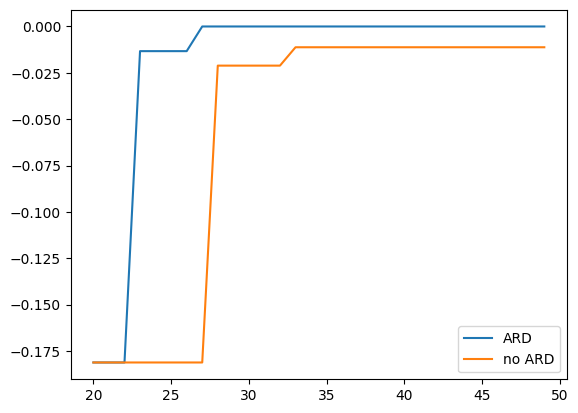

In [6]:
st = n_initial
en = n_initial + n_bayes
steps = np.arange(st, en)
plt.plot(steps, best_fx_ard[st:en], label="ARD")
plt.plot(steps, best_fx_noard[st:en], label="no ARD")
plt.legend()

## 長さスケールの比較

Policy の `get_kernel_length_scale()` メソッドを用いると、学習された長さスケールを取得できます。

- **ard=True**: 次元ごとの値が返されます。小さいほどで重要であることを示します。
- **ard=False**: 1 つのスカラー（等方カーネル）が返されます。

In [7]:
ls_ard = policy_ard.get_kernel_length_scale()
ls_noard = policy_noard.get_kernel_length_scale()

print("--- Kernel length scale ---")
if ls_ard is not None:
    print("ard=True:  per-dimension (smaller = more relevant)")
    for i in range(len(ls_ard)):
        rel = "relevant" if weights[i]>0 else "irrelevant"
        print(f"  dim {i} ({rel}): {ls_ard[i]:.4f}")
else:
    print("ard=True:  (not available)")
if ls_noard is not None:
    print("ard=False: single (isotropic):", ls_noard[0])
else:
    print("ard=False: (not available)")

--- Kernel length scale ---
ard=True:  per-dimension (smaller = more relevant)
  dim 0 (relevant): 2.5764
  dim 1 (relevant): 4.2119
  dim 2 (irrelevant): 5.9329
  dim 3 (irrelevant): 6.0144
ard=False: single (isotropic): 2.200175177775015


## Permutation importance の比較

各次元の値をシャッフルしたときに、予測の MSE がどれだけ増えるかで、その次元の「重要度」を測ります。
値が大きいほど、その次元が予測に効いていることを示します。
ARD の有無によって、重要度の出方も変わります。

In [8]:
imp_mean_ard, imp_std_ard = policy_ard.get_permutation_importance(n_perm=n_perm)
imp_mean_noard, imp_std_noard = policy_noard.get_permutation_importance(n_perm=n_perm)

print("--- Permutation importance ---")
print("ard=True:")
for i in range(D):
    rel = "relevant" if weights[i]>0 else "irrelevant"
    print(f"  dim {i} ({rel}): mean = {imp_mean_ard[i]:.4f}, std = {imp_std_ard[i]:.4f}")
print("ard=False:")
for i in range(D):
    rel = "relevant" if weights[i]>0 else "irrelevant"
    print(f"  dim {i} ({rel}): mean = {imp_mean_noard[i]:.4f}, std = {imp_std_noard[i]:.4f}")
print("(Higher mean => more important.)")

--- Permutation importance ---
ard=True:
  dim 0 (relevant): mean = 83.1582, std = 22.8684
  dim 1 (relevant): mean = 1.4901, std = 0.3866
  dim 2 (irrelevant): mean = 0.1697, std = 0.2088
  dim 3 (irrelevant): mean = 0.2912, std = 0.1730
ard=False:
  dim 0 (relevant): mean = 67.0282, std = 18.2652
  dim 1 (relevant): mean = 16.3441, std = 4.8668
  dim 2 (irrelevant): mean = 7.3731, std = 3.3190
  dim 3 (irrelevant): mean = 6.2181, std = 2.3696
(Higher mean => more important.)
